In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
places = pd.read_csv("clean_places.csv")
restaurants = pd.read_csv("clean_restaurants.csv")
goibibo = pd.read_csv("clean_goibibo.csv")
cleartrip = pd.read_csv("clean_cleartrip.csv")

In [3]:
print("Places:", places.shape)
print("Restaurants:", restaurants.shape)
print("Goibibo:", goibibo.shape)
print("Cleartrip:", cleartrip.shape)

Places: (325, 15)
Restaurants: (6590, 8)
Goibibo: (4000, 33)
Cleartrip: (4882, 31)


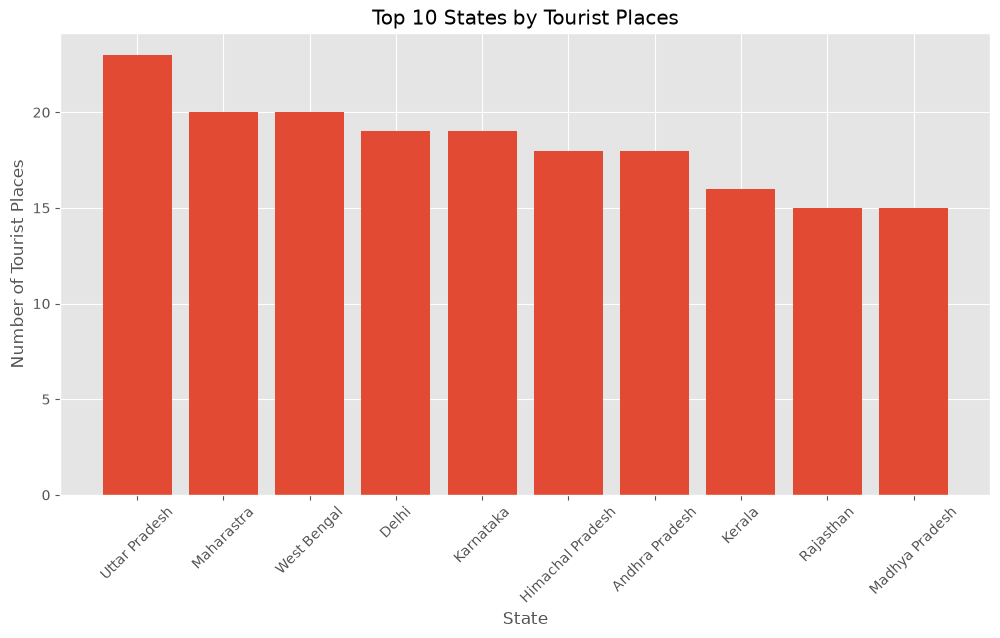

In [4]:
top_states = places["State"].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_states.index, top_states.values)

plt.title("Top 10 States by Tourist Places")
plt.xlabel("State")
plt.ylabel("Number of Tourist Places")

plt.xticks(rotation=45)

plt.show()


In [5]:
print("Places Columns")
print(places.columns.tolist())

print("\nRestaurants Columns")
print(restaurants.columns.tolist())

print("\nGoibibo Columns")
print(goibibo.columns.tolist())

print("\nCleartrip Columns")
print(cleartrip.columns.tolist())

Places Columns
['Zone', 'State', 'City', 'Name', 'Type', 'Establishment Year', 'time needed to visit in hrs', 'Google review rating', 'Entrance Fee in INR', 'Airport with 50km Radius', 'Weekly Off', 'Significance', 'DSLR Allowed', 'Number of google review in lakhs', 'Best Time to visit']

Restaurants Columns
['Name', 'Location', 'Locality', 'City', 'Cuisine', 'Rating', 'Votes', 'Cost']

Goibibo Columns
['additional_info', 'address', 'area', 'city', 'country', 'crawl_date', 'guest_recommendation', 'hotel_category', 'hotel_description', 'hotel_facilities', 'hotel_star_rating', 'image_count', 'latitude', 'locality', 'longitude', 'pageurl', 'point_of_interest', 'property_id', 'property_name', 'property_type', 'province', 'query_time_stamp', 'review_count_by_category', 'room_count', 'room_facilities', 'room_type', 'similar_hotel', 'site_review_count', 'site_review_rating', 'site_stay_review_rating', 'sitename', 'state', 'uniq_id']

Cleartrip Columns
['address', 'area', 'city', 'country', 'c

In [6]:
goibibo_hotel = goibibo[
    [
        "property_name",
        "city",
        "state",
        "property_type",
        "hotel_star_rating",
        "site_review_rating",
        "latitude",
        "longitude",
        "address"
    ]
].copy()

In [7]:
cleartrip_hotel = cleartrip[
    [
        "property_name",
        "city",
        "state",
        "property_type",
        "hotel_star_rating",
        "tad_review_rating",
        "latitude",
        "longitude",
        "address"
    ]
].copy()

In [8]:
goibibo_hotel.rename(columns={
    "property_name":"Name",
    "city":"City",
    "state":"State",
    "property_type":"Type",
    "hotel_star_rating":"Star_Rating",
    "site_review_rating":"Rating"
}, inplace=True)

cleartrip_hotel.rename(columns={
    "property_name":"Name",
    "city":"City",
    "state":"State",
    "property_type":"Type",
    "hotel_star_rating":"Star_Rating",
    "tad_review_rating":"Rating"
}, inplace=True)

In [9]:
hotels = pd.concat(
    [goibibo_hotel, cleartrip_hotel],
    ignore_index=True
)

In [10]:
print(hotels.shape)
hotels.head()

(8882, 9)


,Name,City,State,Type,Star_Rating,Rating,latitude,longitude,address
0,Baragarh Regency,Manali,Himachal Pradesh,Resort,2.0,4.0,32.139387,77.154660,"15th Mile, N.H.21,Manali, District Kullu,Himac..."
1,Asian Suites A- 585,Gurgaon,Haryana,Guest House,0.0,4.5,28.472097,77.072546,"A-585, Sushant Lok-1 ,Near Iffco Chowk Metro S..."
2,Bevvan Resort,Goa,Goa,Resort,0.0,2.5,15.548398,73.757634,"Cobra Vaddo,Calungate Baga Road, Bardez, Calan..."
3,Apple Inn Cottage,Manali,Himachal Pradesh,Cottage,2.0,5.0,32.223603,77.185900,Simsa
4,Anmol Hotel Pvt.Ltd,Delhi,Delhi,Hotel,2.0,2.8,28.646777,77.212735,"8180 Street No.-6,Arakashan Road,Paharganj"


In [11]:
hotels.to_csv("clean_hotels.csv", index=False)

In [12]:
print(hotels.shape)

(8882, 9)


In [20]:
places.insert(0, "Place_ID", range(1, len(places)+1))

restaurants.insert(0, "Restaurant_ID", range(1, len(restaurants)+1))

hotels.insert(0, "Hotel_ID", range(1, len(hotels)+1))

In [21]:
print(places.duplicated().sum())
print(restaurants.duplicated().sum())
print(hotels.duplicated().sum())

0
0
0


In [22]:
places.info()
restaurants.info()
hotels.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Place_ID                          325 non-null    int64  
 1   Zone                              325 non-null    str    
 2   State                             325 non-null    str    
 3   City                              325 non-null    str    
 4   Name                              325 non-null    str    
 5   Type                              325 non-null    str    
 6   Establishment Year                325 non-null    str    
 7   time needed to visit in hrs       325 non-null    float64
 8   Google review rating              325 non-null    float64
 9   Entrance Fee in INR               325 non-null    int64  
 10  Airport with 50km Radius          325 non-null    str    
 11  Weekly Off                        325 non-null    str    
 12  Significance       